# 구간별 여론 분석
---

**연구 대상:** 네이버 블로그·카페의 `의대 증원` 관련 게시글  
**분석 구간:** 2024년 1월부터 2025년 6월까지 4개 section  
**입력:** `data/integrated/crolling_total_estate_press_layered.pkl`  
**출력:** `outputs/analysis/` 하위 CSV·PNG  

**핵심 질문:** `의대 증원`에 대한 온라인 반응이 시간이 지나며 어떻게 바뀌었는가?

**분석 결과 흐름:** 분석 결과의 큰 흐름은 초기에는 정부 발표, 정원 확대, 전공의·환자·진료 차질 같은 의료현장 갈등 인식이 강했고, 시간이 갈수록 대학·전형·수능·수시·등급처럼 입시와 수험 전략에 대한 실질적 관심이 커졌다는 점입니다.

**분석 목적**  
확정된 통합 불용어 레이어 데이터를 기준으로 의대 증원 담론이 `정책·의료갈등`에서 `입시·전형·수험 전략`으로 이동하는 과정을 해석한다.

**입력 데이터**  
`data/integrated/crolling_total_estate_press_layered.pkl`

**해석 관점**  
TF-IDF와 워드클라우드는 시기별 관심 단어를 보여주고, K-Means·LDA·NMF는 담론 유형의 비중 변화를 보여줍니다. 좋아요·댓글 지표는 어떤 담론이 더 많은 공감이나 논쟁 참여를 만들었는지 확인하는 보조 근거로 사용합니다.


## 분석 단계 요약

| 단계 | 질문 | 결론 |
| --- | --- | --- |
| Step 0 | 어떤 시기와 채널에 데이터가 집중되는가 | 3구간에 논의가 가장 집중되고, 블로그는 설명·기사 공유, 카페는 입시·반응형 글을 보완 |
| Step 1 | 최종 토큰이 해석 가능한 정보량을 유지하는가 | 불용어 제거 뒤에도 의료갈등·입시 반응을 해석할 충분한 문서별 토큰이 남음 |
| Step 2 | 시기별 핵심 관심 단어는 무엇인가 | 초기의 정부·정원·전공의에서 후반의 대학·전형·수능·입시로 이동 |
| Step 3 | 빈도와 워드클라우드에서 보이는 담론 인상은 무엇인가 | 의료현장 갈등어는 약해지고 입시·전형어가 반복적으로 커짐 |
| Step 4 | 군집·토픽 구조로도 같은 이동이 보이는가 | KMeans와 LDA 모두 의료갈등 비중 감소, 입시·전형 비중 증가를 보임 |
| Step 5 | 어떤 담론이 더 강한 반응을 만들었는가 | 의료현장 갈등은 논쟁 참여를, 입시 담론은 지속적 실용 관심을 유발 |
| Step 6 | NMF에서도 같은 변화가 확인되는가 | TF-IDF 기반 성분 분해에서도 의료갈등 감소와 수험 전략 증가가 반복 확인됨 |

파일 실행 전 install 부탁드립니다.

```bash
pip install -r requirements.txt
```


---

## 분석 전 경로·라이브러리 로드
PKL·CSV 저장 위치를 한곳에서 맞춥니다.
   - PKL_IN : 02 단계에서 생성한 layered 통합 데이터
   - OUT_DIR : TF-IDF·CSV 등 → outputs/analysis/tfidf/
   - OUT_WC : 워드클라우드 PNG → outputs/analysis/wordcloud/

In [29]:
# 경로 설정에 필요한 기본 모듈입니다.
# sys.path에 프로젝트 폴더를 추가해야 다른 폴더의 공통 모듈을 import할 수 있습니다.
import sys
from pathlib import Path

# 현재 노트북이 실행되는 위치를 기준으로 위쪽 폴더들을 차례대로 확인합니다.
# Jupyter를 프로젝트 루트에서 실행해도, notebooks/03_analysis 안에서 실행해도 같은 경로를 잡기 위한 처리입니다.
_cwd = Path.cwd().resolve()
for _d in [_cwd, *_cwd.parents]:
    # notebook_bootstrap.py가 있는 폴더를 찾으면 그 위치를 공통 유틸 폴더로 판단합니다.
    lib_path = _d / "notebooks" / "lib" / "notebook_bootstrap.py"
    if lib_path.is_file():
        # notebooks/lib 안의 notebook_bootstrap.py, stopword_utils.py를 바로 import할 수 있게 합니다.
        sys.path.insert(0, str(_d / "notebooks" / "lib"))
        break
else:
    # 위쪽 폴더를 모두 확인해도 공통 유틸을 못 찾으면, 잘못된 위치에서 실행 중이라는 뜻입니다.
    raise FileNotFoundError("notebooks/lib/notebook_bootstrap.py 을 찾을 수 없습니다. cwd=" + str(_cwd))

from notebook_bootstrap import setup_paths

# project_paths.py가 있는 프로젝트 루트를 찾고, 루트와 notebooks/lib를 import 경로에 추가합니다.
PROJECT_ROOT = setup_paths()

# stopword_utils.py를 수정한 뒤 노트북을 재실행할 때, 이전에 import된 낡은 모듈을 쓰지 않도록 제거합니다.
sys.modules.pop("stopword_utils", None)

# 프로젝트 전체에서 공통으로 쓰는 데이터·불용어·분석 결과 저장 경로입니다.
from project_paths import (
    DATA_INTEGRATED,              # 통합 분석용 PKL이 들어 있는 data/integrated 폴더
    STOPWORDS_DIR,                # 공통·구간별 불용어 txt가 들어 있는 stopwords 폴더
    OUTPUTS_ANALYSIS_TFIDF,       # TF-IDF CSV와 히트맵 저장 폴더
    OUTPUTS_ANALYSIS_WORDCLOUD,   # 워드클라우드 이미지 저장 폴더
    OUTPUTS_ANALYSIS_KMEANS,      # K-Means 결과 저장 폴더
    OUTPUTS_ANALYSIS_LDA,         # LDA 결과 저장 폴더
)

# 불용어 처리, 토큰 정리, TF-IDF 계산 등에 반복해서 쓰는 함수들입니다.
from stopword_utils import (
    load_stopword_files,           # 여러 불용어 파일을 읽어 하나의 set으로 합침
    ensure_token_list,             # 문자열/NaN/list가 섞인 토큰 컬럼을 list[str]로 통일
    snapshot_noun_columns,         # 원본 명사 컬럼을 *_raw로 백업
    apply_global_clean,            # 전체 문서에 공통 불용어 적용
    row_merged_tokens,             # 제목·본문·댓글 명사를 한 문자열로 병합
    parse_comment_list_cell,       # comment_list 셀을 list[dict] 형태로 복원
    safe_int_comment_cnt,          # 댓글 수를 안전하게 정수로 변환
    apply_local_clean,             # section별 로컬 불용어 적용
    section_mean_tfidf_matrix,     # 전체 코퍼스 기준 TF-IDF 후 section별 평균 계산
    unique_keyword_scores,         # section별 고유 키워드 후보 점수 계산
    document_frequency_from_texts, # 문서 빈도 계산
    sticky_candidates_per_section, # section별 고착어 후보 계산
)

# 데이터 처리와 시각화에 필요한 외부 라이브러리입니다.
import pickle
import warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 자주 쓰는 출력 폴더를 짧은 변수명으로 저장합니다.
OUT_DIR = OUTPUTS_ANALYSIS_TFIDF
OUT_WC = OUTPUTS_ANALYSIS_WORDCLOUD

# 분석 결과 저장 폴더가 없으면 자동 생성합니다.
for _p in (OUT_DIR, OUT_WC, OUTPUTS_ANALYSIS_KMEANS, OUTPUTS_ANALYSIS_LDA):
    _p.mkdir(parents=True, exist_ok=True)

# 02 단계에서 불용어 레이어까지 적용해 저장한 최종 분석 입력 PKL입니다.
PKL_IN = DATA_INTEGRATED / "crolling_total_estate_press_layered.pkl"


전처리에서 확정한 같은 데이터를 모든 분석 모델이 사용하게 하기 위해 분석 경로와 공통 함수를 한 번에 맞췄습니다.

---

## Step 0 — layered PKL 로드 및 검증
02 단계에서 생성한 `crolling_total_estate_press_layered.pkl`을 불러오고, 최종 명사 컬럼(`nouns_final`, `corpus_final`)이 있는지 확인합니다.

출력으로 전체 문서 수, 컬럼 목록, section별 문서 수, 채널별 문서 수, 최종 토큰 형식 이상 여부를 확인합니다.


In [30]:
# 통합 PKL 파일을 읽어 분석용 DataFrame으로 불러옵니다.
with open(PKL_IN, "rb") as f:
    df = pickle.load(f)

required_cols = ["nouns_final", "corpus_final", "section", "ch"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise KeyError("02_integrated/integrated_preprocessing.ipynb를 먼저 실행해 layered PKL을 생성하세요. 누락 컬럼: " + ", ".join(missing_cols))

# 최종 토큰 컬럼은 뒤 단계에서 list 연산을 하므로 형식을 먼저 통일합니다.
df["nouns_final"] = df["nouns_final"].map(ensure_token_list)
df["corpus_final"] = df["corpus_final"].fillna("").astype(str)

# 기본 스키마와 구간·채널 분포를 출력해 입력 데이터가 맞는지 확인합니다.
assert isinstance(df, pd.DataFrame), type(df)
print("shape", df.shape)
print(df.columns.tolist())
print(df["section"].value_counts().sort_index())
print(df["ch"].value_counts().head())
print("nouns_final non-list after ensure:", (~df["nouns_final"].map(lambda x: isinstance(x, list))).sum())


shape (9080, 25)
['title', 'doc', 'like', 'comment_cnt', 'comment_list', 'ch', 'date', 'section', 'title_token_noun', 'document_token_noun', 'comment_token_noun', 'title_token_noun_raw', 'document_token_noun_raw', 'comment_token_noun_raw', 'comment_list_parsed', 'comment_cnt_int', 'title_token_noun_clean', 'document_token_noun_clean', 'comment_token_noun_clean', 'corpus_clean', 'title_token_noun_final', 'document_token_noun_final', 'comment_token_noun_final', 'nouns_final', 'corpus_final']
section
1    2335
2    2439
3    3061
4    1245
Name: count, dtype: Int64
ch
blog    5354
cafe    3726
Name: count, dtype: int64
nouns_final non-list after ensure: 0


### 데이터 분포 해석

- 전체 문서는 9,080건이며, section별 분포는 1구간 2,335건, 2구간 2,439건, 3구간 3,061건, 4구간 1,245건입니다.

- 3구간에 문서가 가장 많이 몰린 것은 의대 증원이 단순 정책 발표를 넘어 수험생·학부모의 실제 입시 판단 문제로 번진 시점에 온라인 관심이 커졌음을 보여줍니다.

- 채널은 블로그 5,354건, 카페 3,726건입니다. 블로그는 정책 설명·기사 공유·개인 해설을 넓게 제공하고, 카페는 등급·전형·지원 전략처럼 당사자 반응을 더 직접적으로 보완하는 자료원으로 확인됩니다.

## Raw 스냅샷 (`*_raw`) 및 보조 컬럼
공통·로컬 불용어를 적용하기 전에 원본 명사 리스트를 `*_raw` 컬럼으로 백업합니다.

또한 댓글 목록은 `comment_list_parsed`로 복원하고, 댓글 수는 `comment_cnt_int`로 숫자형 변환합니다. 출력되는 `describe()` 값은 제목·본문·댓글별 명사 토큰 개수의 규모와 이상치를 확인하는 용도입니다.


In [31]:
# 불용어 제거 전 원본 명사 리스트를 *_raw 컬럼으로 백업합니다.
from tkinter import N


snapshot_noun_columns(df)

# 댓글 원문과 댓글 수를 이후 분석에 쓰기 쉬운 형식으로 변환합니다.
df["comment_list_parsed"] = df["comment_list"].map(parse_comment_list_cell)
df["comment_cnt_int"] = df["comment_cnt"].map(safe_int_comment_cnt)

# raw 명사 개수 통계로 제목·본문·댓글의 정보량을 비교합니다.
for c in ["title_token_noun_raw", "document_token_noun_raw", "comment_token_noun_raw"]:
    print(c, df[c].map(len).describe())

title_token_noun_raw count    9080.000000
mean        6.093943
std         4.140831
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        30.000000
Name: title_token_noun_raw, dtype: float64
document_token_noun_raw count     9080.000000
mean       381.458590
std        981.883244
min          0.000000
25%         60.000000
50%        183.000000
75%        366.000000
max      29896.000000
Name: document_token_noun_raw, dtype: float64
comment_token_noun_raw count    9080.000000
mean       77.139537
std       173.974802
min         0.000000
25%         6.000000
50%        19.000000
75%        67.000000
max      3229.000000
Name: comment_token_noun_raw, dtype: float64


## 원본 명사 개수 박스플롯
Raw 스냅샷 직후 제목·본문·댓글 명사 개수를 각각 박스플롯으로 확인합니다.

본문 토큰 수가 제목·댓글보다 훨씬 클 수 있으므로 세 축을 분리해 이상치 때문에 작은 분포가 눌려 보이지 않도록 합니다. 


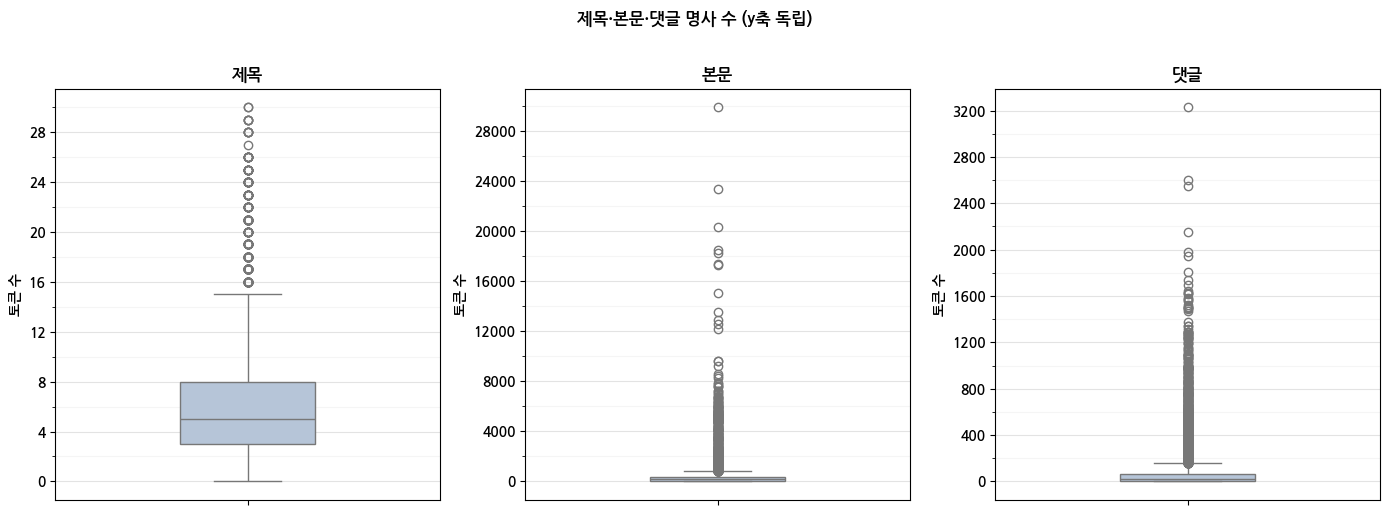

In [32]:
# 한글 축·제목이 깨지지 않도록 나눔고딕 폰트를 등록합니다.
from matplotlib import font_manager

_nanum_ttf = PROJECT_ROOT / "nanum-gothic" / "NanumGothicBold.ttf"
if not _nanum_ttf.is_file():
    raise FileNotFoundError(
        f"나눔고딕 폰트가 없습니다: {_nanum_ttf}\n"
        "프로젝트 루트에 nanum-gothic/NanumGothicBold.ttf 를 두세요."
    )
font_manager.fontManager.addfont(str(_nanum_ttf))
_nanum_name = font_manager.FontProperties(fname=str(_nanum_ttf)).get_name()
plt.rcParams["font.family"] = [_nanum_name]
plt.rcParams["axes.unicode_minus"] = False

# 제목·본문·댓글별 raw 명사 개수를 시각화용 표로 만듭니다.
plot_df = pd.DataFrame(
    {
        "제목": df["title_token_noun_raw"].map(len),
        "본문": df["document_token_noun_raw"].map(len),
        "댓글": df["comment_token_noun_raw"].map(len),
    }
)

# 한 figure에 3개 박스 — y축 범위를 각각 독립(본문 이상치가 제목·댓글 축을 눌러서 박스가 안 보이는 문제 방지)
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cols = ["제목", "본문", "댓글"]
for ax, col in zip(axes, cols):
    sns.boxplot(y=plot_df[col], ax=ax, width=0.35, color="lightsteelblue")
    ax.set_title(col)
    ax.set_ylabel("토큰 수")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelbottom=False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=10, min_n_ticks=8))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, which="major", axis="y", alpha=0.35)
    ax.grid(True, which="minor", axis="y", alpha=0.12)

fig.suptitle("제목·본문·댓글 명사 수 (y축 독립)", y=1.02)
plt.tight_layout()
plt.show()

### 원본 명사 수 boxplot 해석

- 제목은 평균 약 6개의 명사로 구성되어 있어 `의대 증원`, `전공의`, `수능`, `전형`처럼 게시글의 핵심 관심사를 압축적으로 드러냅니다.
- 본문은 평균 약 381개의 명사를 포함해 정책 설명, 의료현장 갈등, 입시 영향 해설을 가장 풍부하게 담고 있습니다. 표준편차가 큰 것은 짧은 공유글부터 긴 해설·논평형 글까지 함께 존재한다는 뜻입니다.
- 댓글은 평균 약 77개의 명사로 본문보다 짧지만, 정책 찬반보다도 불안·질문·조언·반박 같은 즉각 반응을 확인하는 데 의미가 있습니다.
- 명사 수가 0인 행은 일부 존재하지만 전체 흐름을 흔들 정도는 아니라고 생각하며, 이후 최종 토큰 검증에서 분석 가능한 문서만 유지되는지 다시 확인합니다.

---


## Step 1 — 불용어 레이어 확인
공통 불용어와 구간별 로컬 불용어 적용은 02 단계에서 완료했습니다.

이 단계에서는 `nouns_final`과 `corpus_final`이 정상적으로 들어 있는지 확인만 합니다.


In [33]:
# 02 단계에서 만든 최종 토큰 길이를 확인합니다.
print(df["nouns_final"].map(len).describe())
print(df["corpus_final"].str.split().map(len).describe())

count     9080.000000
mean       360.876542
std        815.280452
min          1.000000
25%        100.750000
50%        192.000000
75%        345.000000
max      27299.000000
Name: nouns_final, dtype: float64
count     9080.000000
mean       361.126762
std        816.167515
min          1.000000
25%        100.750000
50%        192.000000
75%        345.000000
max      27383.000000
Name: corpus_final, dtype: float64


### 최종 토큰 정보량 해석

- `nouns_final`은 문서당 평균 약 361개의 토큰을 유지합니다. 불용어를 제거했음에도 정보량이 충분히 남아 있어 TF-IDF, 군집, 토픽 모델링으로 의대 증원 반응의 변화를 비교할 수 있습니다.
- 최소 토큰 수가 1 이상으로 유지되므로, 분석 단계에서 비어 있는 문서가 주요 결과를 왜곡할 가능성은 낮습니다.
- 제목·본문·댓글을 합친 최종 토큰은 정책 설명, 의료현장 갈등, 입시 질문, 댓글 반응을 한 문서 단위로 함께 보게 해줍니다. 따라서 `정부·전공의·환자` 중심 반응과 `수능·전형·등급` 중심 반응을 같은 기준에서 비교할 수 있습니다.

---


## Step 2 — 확정 토큰 기준 섹션별 TF-IDF
02 단계에서 확정한 `corpus_final` 전체에 TF-IDF를 한 번 학습한 뒤, 같은 어휘 공간에서 section별 평균 TF-IDF를 계산합니다.

첫 표는 어느 section에서든 두드러진 단어를 전체적으로 확인하기 위한 wide matrix입니다. 저장 파일은 `outputs/analysis/tfidf/tfidf_section_mean_wide.csv`입니다.


In [34]:
# TF-IDF 계산에 사용할 문서 문자열과 section 라벨을 준비합니다.
texts = df["corpus_final"].fillna("").astype(str).tolist()
sections = df["section"].to_numpy()

# 전체 코퍼스 기준 TF-IDF를 계산한 뒤 section별 평균 행렬을 만듭니다.
wide_tfidf, vec, X = section_mean_tfidf_matrix(
    texts, sections, section_ids=(1, 2, 3, 4), min_df=2, max_df=0.98
)
print("wide shape", wide_tfidf.shape)

# CSV·표: 4개 섹션 중 **최대 평균 TF-IDF** 기준 내림차순(어느 분기에서든 두드러진 단어가 위로)
# 어느 section에서든 점수가 높은 단어가 위에 오도록 최대 TF-IDF 기준으로 정렬합니다.
_wide_sorted = (
    wide_tfidf.assign(_peak=wide_tfidf.max(axis=1))
    .sort_values("_peak", ascending=False)
    .drop(columns="_peak")
)
_wide_sorted.to_csv(OUT_DIR / "tfidf_section_mean_wide.csv", encoding="utf-8-sig")

_wide_sorted.head(15)


wide shape (35920, 4)


,section_1_mean_tfidf,section_2_mean_tfidf,section_3_mean_tfidf,section_4_mean_tfidf
정부,0.056332,0.041122,0.029561,0.021684
정원,0.053134,0.029438,0.019705,0.026607
지역,0.040072,0.028526,0.020665,0.022591
전공의,0.037586,0.020816,0.020554,0.011147
대학,0.037046,0.034865,0.031264,0.030975
수능,0.017326,0.021316,0.036502,0.025660
입시,0.020181,0.027723,0.027486,0.034848
감사,0.020961,0.000000,0.026066,0.033361
전형,0.019972,0.033065,0.028194,0.026986
국민,0.032858,0.023705,0.021469,0.012557


### TF-IDF wide matrix 해석

전체 어휘 공간에서 section별 평균 TF-IDF를 계산하여 단순히 많이 나온 단어가 아니라 특정 구간에서 상대적으로 더 중요해진 단어를 볼 수 확인했습니다. 이 표에서 `정부`, `전공의`, `환자`의 상대적 중요도는 앞 구간에서 높고, `수능`, `입시`, `전형`은 뒤 구간에서 커지는 흐름을 보여줍니다. 
- 따라서 의대 증원 논의가 의료현장 갈등에서 입시 영향 논의로 이동했다는 해석의 1차 근거가 됩니다.


## 섹션별 고유 키워드 후보
각 section의 평균 TF-IDF에서 다른 section들의 최대값을 뺀 `diff` 점수로, 특정 시기에만 상대적으로 두드러진 단어를 찾습니다.

section별 상위 80개 후보는 `outputs/analysis/tfidf/unique_keyword_candidates_section{n}.csv`에 저장됩니다.


In [35]:
# section별 TF-IDF가 다른 section보다 얼마나 높은지 diff 점수를 계산합니다.
scored = unique_keyword_scores(wide_tfidf, section_ids=(1, 2, 3, 4))

# 각 section의 고유 키워드 후보 상위 80개를 CSV로 저장합니다.
for s in (1, 2, 3, 4):
    col = f"diff_vs_others_max_s{s}"
    top = scored.sort_values(col, ascending=False).head(80)
    top.to_csv(OUT_DIR / f"unique_keyword_candidates_section{s}.csv", encoding="utf-8-sig")
    print("section", s, "top diff term:", top.index[0], float(top.iloc[0][col]))

section 1 top diff term: 정원 0.023695240042142997
section 2 top diff term: 휴진 0.02049617174609604
section 3 top diff term: 수시 0.011470181840340137
section 4 top diff term: 발표 0.02151237613539947


#### 섹션별 핵심 키워드 해석

- 1구간은 `정부`, `정원`, `전공의`, `환자`, `진료`가 강하게 나타나 정책 발표 직후의 반응이 의료공백, 정부 책임, 현장 갈등에 집중되어 있었음을 보여줍니다.
- 2구간은 `대학`, `전형`, `지역`, `학생`, `입시`가 함께 올라오며 의대 증원이 더 이상 의료정책만의 문제가 아니라 대학 선발 구조와 지역 인재 논의로 연결되기 시작한 시기입니다.
- 3구간은 `수능`, `수시`, `지원`, `감사`, `모집`이 강화되어 수험생과 학부모가 실제 지원 전략, 전형 변화, 제도 검증 문제를 본격적으로 따지기 시작한 흐름으로 해석됩니다.
- 4구간은 `감사`, `전형`, `입시`, `준비`, `정시`가 중심이 되어 정책 찬반보다 확정된 변화에 어떻게 대응할지, 어떤 전형을 준비할지에 대한 실용적 관심이 커진 모습입니다.


## 고착어 후보 산출 위치
고착어 후보 산출과 로컬 불용어 반영 및 sectio별 고착어 후보는 02 단계에서 수행합니다.

03 분석 노트북은 확정된 `nouns_final`과 `corpus_final`을 사용하므로 이 단계에서 불용어 후보를 다시 만들지 않습니다.


In [51]:
print("고착어 후보 CSV는 02_integrated/integrated_preprocessing.ipynb에서 생성합니다.")
print("section별 고착어 후보 CSV는 02_integrated/integrated_preprocessing.ipynb에서 생성합니다.")

고착어 후보 CSV는 02_integrated/integrated_preprocessing.ipynb에서 생성합니다.
section별 고착어 후보 CSV는 02_integrated/integrated_preprocessing.ipynb에서 생성합니다.


### 최종 토큰 확인
로컬 불용어 적용과 `nouns_final`, `corpus_final` 생성은 02 단계에서 완료됩니다.

이 셀은 03 분석 전에 최종 토큰 길이만 다시 확인합니다.


In [38]:
# 02 단계에서 확정된 최종 명사 컬럼을 확인합니다.
print(df["nouns_final"].map(len).describe())
print(df["corpus_final"].str.split().map(len).describe())

count     9080.000000
mean       360.876542
std        815.280452
min          1.000000
25%        100.750000
50%        192.000000
75%        345.000000
max      27299.000000
Name: nouns_final, dtype: float64
count     9080.000000
mean       361.126762
std        816.167515
min          1.000000
25%        100.750000
50%        192.000000
75%        345.000000
max      27383.000000
Name: corpus_final, dtype: float64


### 토큰 길이 해석

- 최종 토큰 길이가 안정적으로 유지되므로 section별 비교에서 특정 구간이 전처리 때문에 과도하게 비거나 과장될 가능성은 낮다고 예상합니다. 

---

## Step 3 — 빈도, WordCloud, 히트맵
최종 토큰(`nouns_final`, `corpus_final`)을 기준으로 section별 상위 빈도어, 워드클라우드, TF-IDF 히트맵을 생성합니다.

첫 코드 셀은 section별 상위 빈도어 표를 만들고 `outputs/analysis/tfidf/section_top_word_frequency.csv`에 저장합니다.


### 상위 빈도어 해석

- 1구간은 `정부`, `정원`, `전공의`, `환자`, `진료`가 강해 의대 증원이 의료체계와 현장 갈등의 문제로 인식되었습니다. 2구간 이후에는 `대학`, `전형`, `학생`, `입시`, `수능`이 함께 커지며 정책 이슈가 입시 제도와 수험 전략의 문제로 재구성됩니다.


## WordCloud
section별 `nouns_final`을 하나의 문자열로 합쳐 2×2 워드클라우드를 그립니다.

한글 표시를 위해 앞 셀에서 로드한 나눔고딕 폰트(`_nanum_ttf`)를 사용하며, 결과 이미지는 `outputs/analysis/wordcloud/wordcloud_by_section.png`에 저장됩니다.


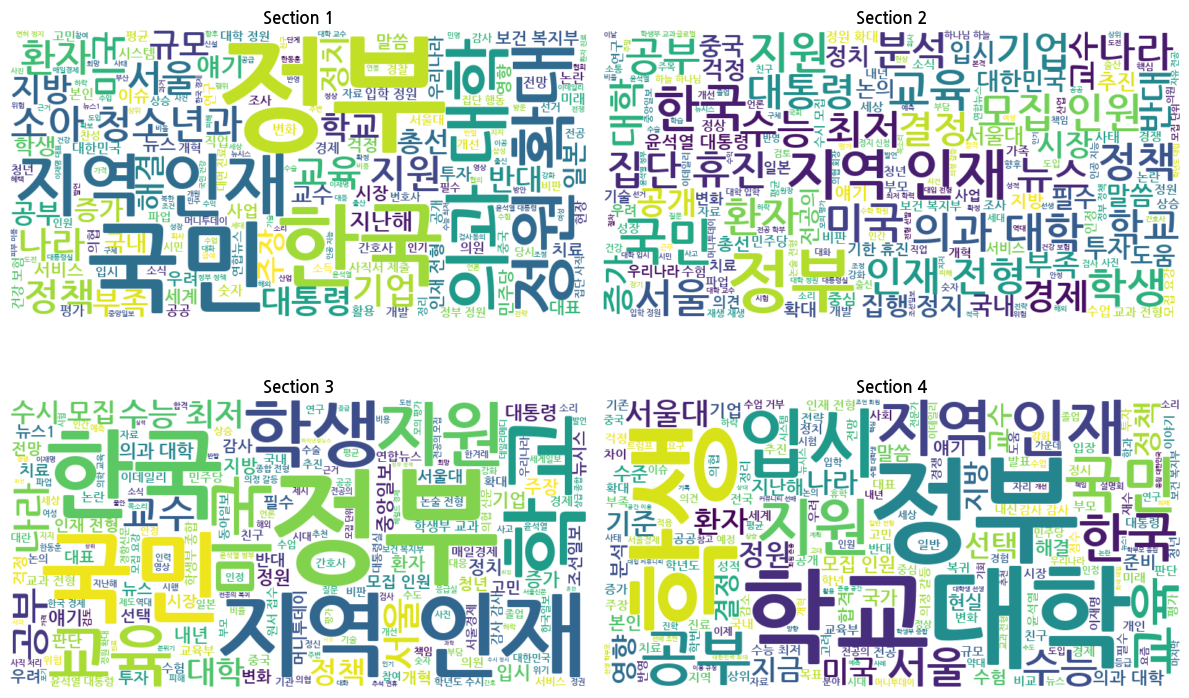

In [40]:
# 최종 명사 리스트를 section별 워드클라우드로 시각화합니다.
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, s in enumerate((1, 2, 3, 4)):
    ax = axes.ravel()[i]
    # 해당 section의 모든 토큰을 하나의 문자열로 합쳐 WordCloud 입력으로 사용합니다.
    text = " ".join(w for row in df.loc[df["section"] == s, "nouns_final"] for w in row)
    wc = (
        WordCloud(font_path=str(_nanum_ttf), width=800, height=400, background_color="white").generate(text)
        if text.strip()
        else None
    )
    if wc:
        ax.imshow(wc, interpolation="bilinear")
    else:
        ax.text(0.5, 0.5, "(empty)", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"Section {s}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_WC / "wordcloud_by_section.png", dpi=150, bbox_inches="tight")
plt.show()

### WordCloud 해석

- 1구간에서는 `정부`, `정원`, `전공의`, `환자`가 크게 보이며 정책 발표와 의료현장 충돌이 핵심 인식이었습니다. 3~4구간으로 갈수록 `대학`, `전형`, `수능`, `입시`, `지원`이 커져, 담론이 수험생·학부모의 실제 선택 문제로 이동한 모습이 두드러집니다.


## TF-IDF 히트맵
section별 고유 키워드 후보 상위 단어를 합친 뒤, 같은 단어들이 1~4구간에서 어떤 TF-IDF 강도를 보이는지 히트맵으로 비교합니다.

결과 이미지는 `outputs/analysis/tfidf/tfidf_heatmap_union_top.png`에 저장됩니다.


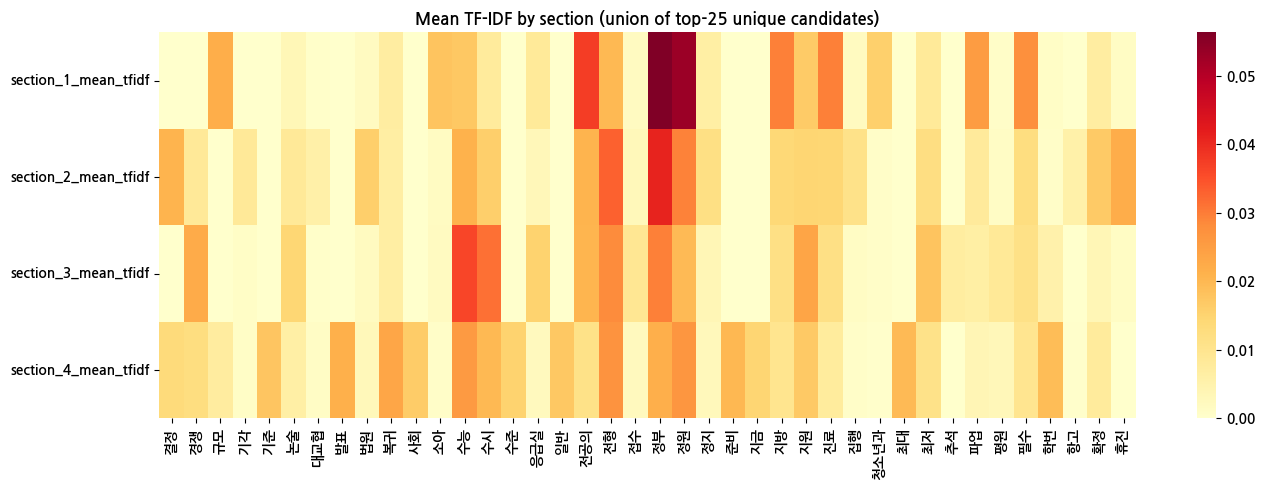

In [41]:
# section별 고유 키워드 후보 상위 단어를 합쳐 히트맵에 표시할 단어 목록을 만듭니다.
union_terms = set()
for s in (1, 2, 3, 4):
    union_terms.update(scored.sort_values(f"diff_vs_others_max_s{s}", ascending=False).head(10).index)
union_terms = sorted(union_terms)
# wide TF-IDF 행렬에서 선택 단어만 뽑아 section x term 형태로 바꿉니다.
heat = wide_tfidf.reindex(union_terms).T
plt.figure(figsize=(max(10, len(union_terms) * 0.35), 5))
sns.heatmap(heat, cmap="YlOrRd", xticklabels=True)
plt.title("Mean TF-IDF by section (union of top-25 unique candidates)")
plt.tight_layout()
plt.savefig(OUT_DIR / "tfidf_heatmap_union_top.png", dpi=150, bbox_inches="tight")
plt.show()

#### TF-IDF 히트맵 해석

- 의대 증원 담론의 무게중심이 시간에 따라 바뀌는 모습을 압축적으로 확인해봤습니다. 1구간에서는 `정부`, `정원`, `전공의`, `환자`, `진료`가 상대적으로 강해 정책 발표와 의료공백 우려가 중심이었습니다. 2구간부터는 `대학`, `전형`, `지역`, `학생`, `입시`가 함께 커지며 정책 이슈가 대입 제도 문제로 연결됩니다. 3~4구간에서는 `수능`, `수시`, `지원`, `모집`, `정시`, `감사`가 반복적으로 나타나, 후반으로 갈수록 사람들의 관심이 찬반 논쟁보다 실제 입시 대응과 제도 검증으로 이동했음을 알 수 있습니다.

## layered PKL 저장 위치
`crolling_total_estate_press_layered.pkl` 저장은 02 단계에서 수행합니다.

03 단계에서는 같은 파일을 다시 저장하지 않고 최종 분석 산출물만 생성합니다.


In [42]:
print("layered PKL 저장은 02_integrated/integrated_preprocessing.ipynb에서 수행합니다.")

layered PKL 저장은 02_integrated/integrated_preprocessing.ipynb에서 수행합니다.


---
## Step 4 — 구간별 KMeans · LDA (`nouns_final` 기반)

### Step 4a — 데이터 준비

02 단계의 layered PKL을 읽은 메모리의 `df`에서 `doc_text_filtered`를 만듭니다.

이 셀은 같은 `analysis_df`와 같은 구간 이름을 기준으로 KMeans, LDA, NMF가 모두 비교되도록 준비합니다. 모델마다 입력 행렬은 다르지만 section 기준을 통일했기 때문에, 이후 결과에서 보이는 차이는 데이터 범위 차이가 아니라 담론 분류 방식의 차이로 해석할 수 있습니다.


In [43]:
# K-Means와 LDA 실행에 필요한 모델링 라이브러리와 표시 도구를 불러옵니다.
import pickle
from pathlib import Path

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import silhouette_score

from project_paths import (
    DATA_INTEGRATED,
    OUTPUTS_ANALYSIS_KMEANS,
    OUTPUTS_ANALYSIS_LDA,
)

# 모델링 결과를 저장할 하위 폴더를 준비합니다.
KMEANS_DIR = OUTPUTS_ANALYSIS_KMEANS
LDA_DIR = OUTPUTS_ANALYSIS_LDA
for _p in (KMEANS_DIR, LDA_DIR):
    _p.mkdir(parents=True, exist_ok=True)

KMEANS_N_CLUSTERS = 3
LDA_N_TOPICS = 5
TOP_N_WORDS = 15
SECTION_NAME_MAP = {
    1: "1구간 (2024.01~03)",
    2: "2구간 (2024.04~06)",
    3: "3구간 (2024.07~12)",
    4: "4구간 (2025.01~06)",
}
SECTION_ORDER = [SECTION_NAME_MAP[i] for i in sorted(SECTION_NAME_MAP)]

# Step 4에서 모델 결과와 그래프가 바로 해석되도록 라벨을 먼저 정의합니다.
# 라벨은 저장된 상위 키워드와 실제 출력 결과를 기준으로 붙였습니다.
cluster_label_map = {
    0: "정책·사회/교육 혼합형",
    1: "의료현장 갈등형",
    2: "입시·전형 집중형",
}
topic_label_map = {
    0: "의료현장·진료 차질",
    1: "경제·시장 외부담론",
    2: "정책·의료갈등 종합",
    3: "정치·선거 담론",
    4: "입시·전형 담론",
}


def label_from_map(value, mapping, prefix):
    """숫자 ID와 해석 라벨을 함께 보여주는 표시명을 만듭니다."""
    value = int(value)
    return f"{prefix} {value}: {mapping.get(value, '미지정')}"


# 리스트·결측·문자열이 섞일 수 있는 텍스트 값을 모델 입력용 문자열로 정규화합니다.
def normalize_text(value):
    if isinstance(value, list):
        value = " ".join(map(str, value))
    if pd.isna(value):
        return ""
    return " ".join(str(value).split())


def save_csv_utf8(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")


def extract_top_terms(weights, feature_names, item_name, top_n=15):
    rows = []
    for item_id, item_weights in enumerate(weights):
        top_indices = item_weights.argsort()[::-1][:top_n]
        for rank, idx in enumerate(top_indices, start=1):
            rows.append(
                {
                    item_name: item_id,
                    "rank": rank,
                    "keyword": feature_names[idx],
                    "weight": float(item_weights[idx]),
                }
            )
    return pd.DataFrame(rows)


def build_section_ratio_table(df: pd.DataFrame, value_col: str):
    out = (
        df.groupby(["section", "section_name", value_col])
        .size()
        .rename("doc_count")
        .reset_index()
    )
    out["section_total"] = out.groupby("section")["doc_count"].transform("sum")
    out["ratio"] = out["doc_count"] / out["section_total"]
    return out


# 앞 단계의 df가 없으면 저장된 layered PKL에서 다시 불러옵니다.
if "df" not in dir():
    df = None
if df is None or "nouns_final" not in df.columns:
    _pkl = DATA_INTEGRATED / "crolling_total_estate_press_layered.pkl"
    with open(_pkl, "rb") as f:
        df = pickle.load(f)
    print("loaded", _pkl)
else:
    print("using in-memory df from Step 5")

# 모델링에 필요한 최소 컬럼만 남기기 전에 분석용 복사본을 만듭니다.
analysis_df = df.copy()
analysis_df["doc_text_filtered"] = analysis_df["nouns_final"].map(
    lambda xs: " ".join(str(w) for w in xs) if isinstance(xs, list) else normalize_text(xs)
)
for col in ["like", "comment_cnt"]:
    if col not in analysis_df.columns:
        analysis_df[col] = 0
analysis_df["doc_text_filtered"] = analysis_df["doc_text_filtered"].apply(normalize_text)
analysis_df["section"] = pd.to_numeric(analysis_df["section"], errors="coerce")
analysis_df["date"] = pd.to_datetime(analysis_df.get("date", pd.NaT), errors="coerce")
analysis_df["like"] = pd.to_numeric(analysis_df["like"], errors="coerce").fillna(0).astype(int)
analysis_df["comment_cnt"] = pd.to_numeric(analysis_df["comment_cnt"], errors="coerce").fillna(0).astype(int)
analysis_df = analysis_df[["title", "date", "section", "like", "comment_cnt", "doc_text_filtered"]].copy()
analysis_df = analysis_df.dropna(subset=["section", "doc_text_filtered"])
analysis_df = analysis_df[analysis_df["doc_text_filtered"].str.len() > 0].copy()
analysis_df["section"] = analysis_df["section"].astype(int)
analysis_df["section_name"] = analysis_df["section"].map(SECTION_NAME_MAP)
analysis_df["token_count"] = analysis_df["doc_text_filtered"].str.split().str.len()
analysis_df = analysis_df.sort_values(["section", "date", "title"]).reset_index(drop=True)
print("documents:", len(analysis_df))

using in-memory df from Step 5
documents: 9080


### Step 4b — KMeans


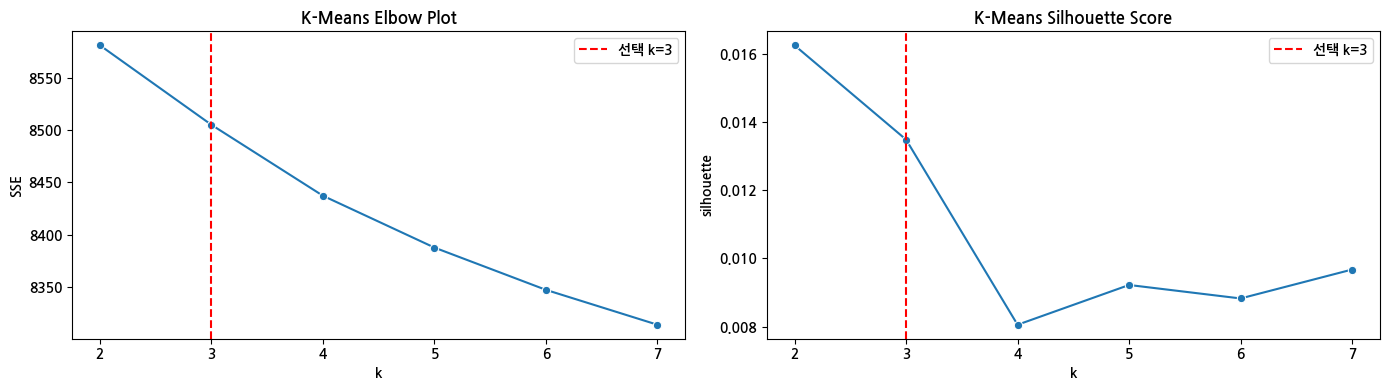

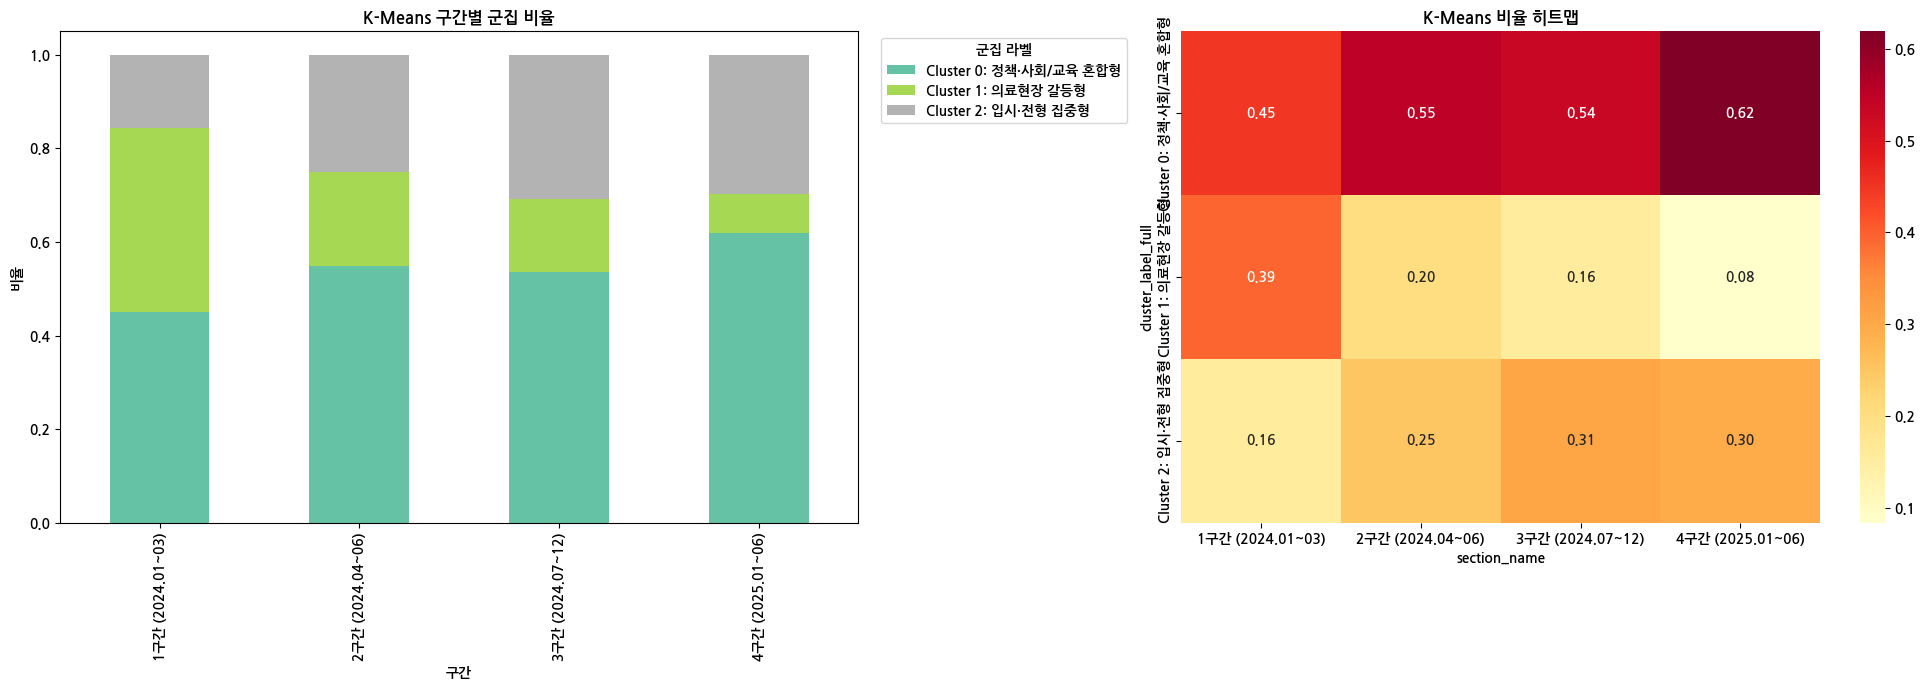

Step 4b (KMeans) done — outputs under kmeans/


In [ ]:
# K-Means는 TF-IDF 벡터를 입력으로 사용합니다.
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.85)
tfidf_matrix = tfidf_vectorizer.fit_transform(analysis_df["doc_text_filtered"])

# k 후보별 SSE와 silhouette score를 함께 계산해 군집 수 선택 근거를 만듭니다.
model_selection_rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(tfidf_matrix)
    model_selection_rows.append(
        {
            "k": k,
            "sse": km.inertia_,
            # 전체 pairwise 거리 계산은 오래 걸리므로 재현 가능한 표본으로 silhouette을 계산합니다.
            "silhouette": silhouette_score(tfidf_matrix, labels, sample_size=min(2000, tfidf_matrix.shape[0]), random_state=42),
            "selected": k == KMEANS_N_CLUSTERS,
        }
    )
kmeans_model_selection_df = pd.DataFrame(model_selection_rows)
save_csv_utf8(kmeans_model_selection_df, KMEANS_DIR / "kmeans_model_selection.csv")
save_csv_utf8(kmeans_model_selection_df[["k", "sse"]], KMEANS_DIR / "kmeans_elbow.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=kmeans_model_selection_df, x="k", y="sse", marker="o", ax=axes[0])
axes[0].axvline(KMEANS_N_CLUSTERS, color="red", linestyle="--", label=f"선택 k={KMEANS_N_CLUSTERS}")
axes[0].set_title("K-Means Elbow Plot")
axes[0].set_xlabel("k")
axes[0].set_ylabel("SSE")
axes[0].legend()

sns.lineplot(data=kmeans_model_selection_df, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].axvline(KMEANS_N_CLUSTERS, color="red", linestyle="--", label=f"선택 k={KMEANS_N_CLUSTERS}")
axes[1].set_title("K-Means Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
axes[1].legend()
plt.tight_layout()
plt.show()

# 선택한 군집 수로 최종 K-Means 모델을 학습하고 문서별 군집을 붙입니다.
kmeans_model = KMeans(n_clusters=KMEANS_N_CLUSTERS, n_init=20, random_state=42)
analysis_df["cluster"] = kmeans_model.fit_predict(tfidf_matrix)
analysis_df["cluster_label"] = analysis_df["cluster"].map(cluster_label_map)
analysis_df["cluster_label_full"] = analysis_df["cluster"].map(lambda x: label_from_map(x, cluster_label_map, "Cluster"))
tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
kmeans_top_terms_df = extract_top_terms(
    weights=kmeans_model.cluster_centers_,
    feature_names=tfidf_feature_names,
    item_name="cluster",
    top_n=TOP_N_WORDS,
)
kmeans_top_terms_df["cluster_label"] = kmeans_top_terms_df["cluster"].map(cluster_label_map)
cluster_size_df = analysis_df["cluster"].value_counts().sort_index().rename("cluster_size")
kmeans_top_terms_df = kmeans_top_terms_df.merge(
    cluster_size_df, left_on="cluster", right_index=True, how="left"
)
save_csv_utf8(kmeans_top_terms_df, KMEANS_DIR / "kmeans_cluster_top_terms.csv")

kmeans_doc_df = analysis_df[
    ["title", "date", "section", "section_name", "like", "comment_cnt", "cluster", "cluster_label", "cluster_label_full"]
].copy()
save_csv_utf8(kmeans_doc_df, KMEANS_DIR / "kmeans_doc_assignments.csv")

# section별로 각 군집이 차지하는 비율을 계산해 시각화용 pivot으로 바꿉니다.
kmeans_section_distribution = build_section_ratio_table(kmeans_doc_df, value_col="cluster")
kmeans_section_distribution["cluster_label"] = kmeans_section_distribution["cluster"].map(cluster_label_map)
kmeans_section_distribution["cluster_label"] = kmeans_section_distribution["cluster"].map(
    lambda x: label_from_map(x, cluster_label_map, "Cluster")
)
save_csv_utf8(kmeans_section_distribution, KMEANS_DIR / "kmeans_section_distribution.csv")

kmeans_pivot = kmeans_section_distribution.pivot(
    index="section_name", columns="cluster_label_full", values="ratio"
)
kmeans_column_order = [label_from_map(i, cluster_label_map, "Cluster") for i in range(KMEANS_N_CLUSTERS)]
kmeans_pivot = kmeans_pivot.reindex(index=SECTION_ORDER).reindex(columns=kmeans_column_order).fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
kmeans_pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("K-Means 구간별 군집 비율")
axes[0].set_xlabel("구간")
axes[0].set_ylabel("비율")
axes[0].legend(title="군집 라벨", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.heatmap(kmeans_pivot.T, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("K-Means 비율 히트맵")
plt.tight_layout()
plt.show()
print("Step 4b (KMeans) done — outputs under kmeans/")

### KMeans 결과 해석

- KMeans는 전체 문서를 세 가지 담론 유형으로 나누어 구간별 비중 변화를 보여줍니다. `의료현장 갈등형`은 1구간 39.4%에서 4구간 8.4%로 크게 줄어, 초반의 의료공백·전공의·환자 피해 인식이 시간이 지나며 약해졌음을 뜻합니다. 반대로 `입시·전형 집중형`은 1구간 15.7%에서 3구간 30.9%, 4구간 29.7%로 커져, 후반부에는 의대 증원이 수험 전략과 전형 변화의 문제로 받아들여졌음을 보여줍니다.


### Step 4c — LDA


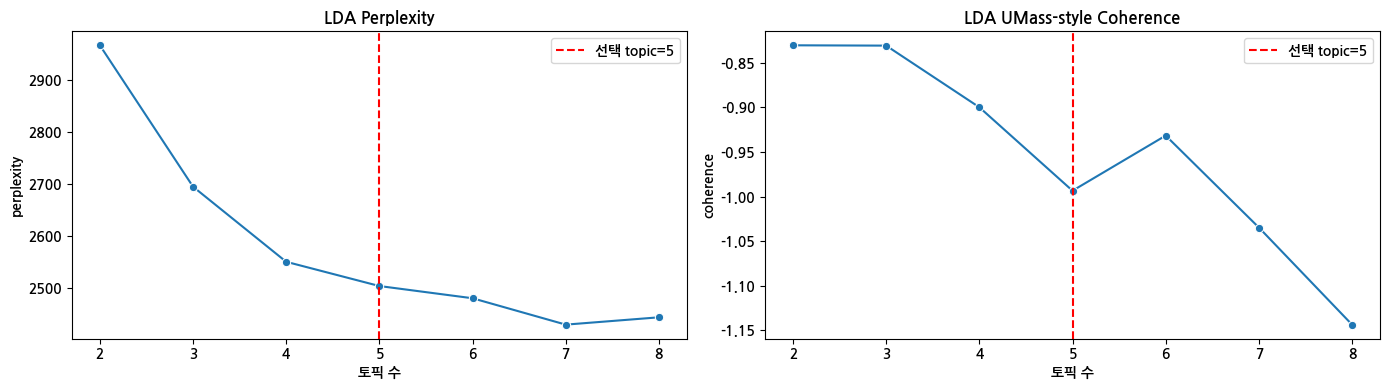

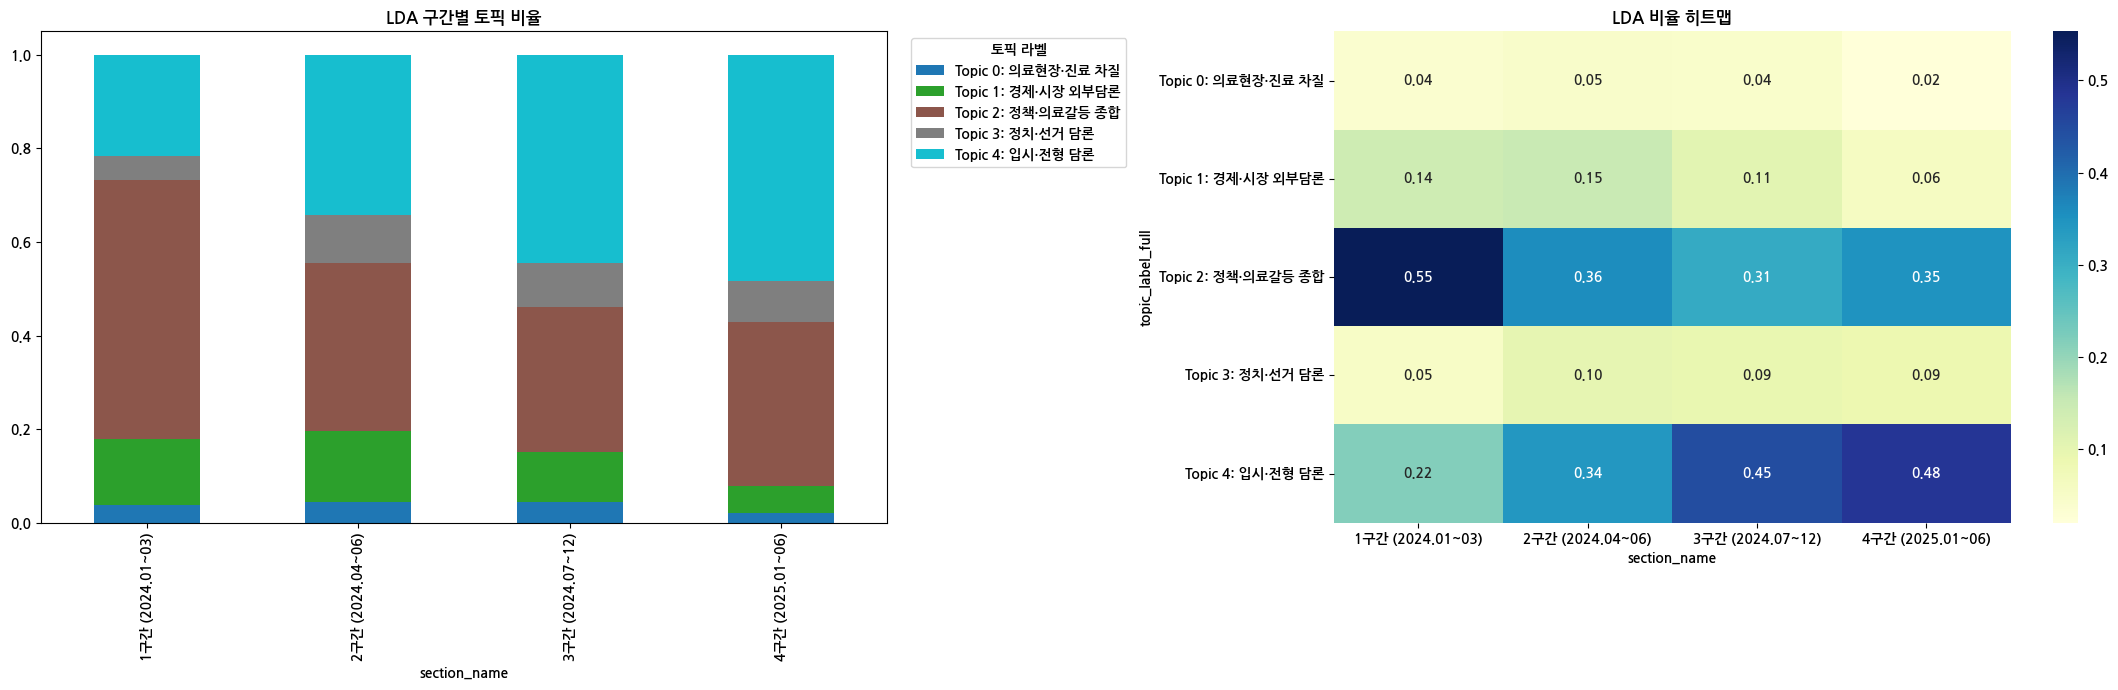

Step 4c (LDA) done — outputs under lda/


In [45]:
# LDA는 단어 등장 횟수 기반 행렬을 입력으로 사용합니다.
count_vectorizer = CountVectorizer(min_df=5, max_df=0.85)
count_matrix = count_vectorizer.fit_transform(analysis_df["doc_text_filtered"])
count_feature_names = np.array(count_vectorizer.get_feature_names_out())


def umass_coherence(model, doc_term_matrix, top_n=10):
    """상위 단어 동시출현으로 UMass-style coherence를 계산합니다. 값이 0에 가까울수록 해석 일관성이 좋습니다."""
    binary_matrix = (doc_term_matrix > 0).astype(int)
    word_doc_freq = np.asarray(binary_matrix.sum(axis=0)).ravel()
    topic_scores = []
    for topic_weights in model.components_:
        top_indices = topic_weights.argsort()[::-1][:top_n]
        pair_scores = []
        for m in range(1, len(top_indices)):
            for l in range(m):
                word_m = top_indices[m]
                word_l = top_indices[l]
                cooccur = binary_matrix[:, word_m].multiply(binary_matrix[:, word_l]).sum()
                pair_scores.append(np.log((cooccur + 1) / max(word_doc_freq[word_l], 1)))
        topic_scores.append(float(np.mean(pair_scores)) if pair_scores else np.nan)
    return float(np.nanmean(topic_scores))


# 토픽 수 후보별 perplexity와 coherence를 계산해 LDA_N_TOPICS 선택 근거를 남깁니다.
# 전체 후보 비교는 오래 걸리므로 재현 가능한 표본 행렬로 계산하고, 최종 모델은 전체 행렬로 학습합니다.
lda_eval_sample_size = min(3000, count_matrix.shape[0])
lda_eval_indices = np.random.default_rng(42).choice(count_matrix.shape[0], size=lda_eval_sample_size, replace=False)
lda_eval_matrix = count_matrix[lda_eval_indices]

lda_selection_rows = []
for n_topics in range(2, 9):
    candidate_model = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=10,
        learning_method="online",
        random_state=42,
        n_jobs=-1,
    )
    candidate_model.fit(lda_eval_matrix)
    lda_selection_rows.append(
        {
            "n_topics": n_topics,
            "perplexity": candidate_model.perplexity(lda_eval_matrix),
            "umass_coherence": umass_coherence(candidate_model, lda_eval_matrix, top_n=10),
            "selected": n_topics == LDA_N_TOPICS,
        }
    )
lda_model_selection_df = pd.DataFrame(lda_selection_rows)
save_csv_utf8(lda_model_selection_df, LDA_DIR / "lda_model_selection.csv")

fig_eval, eval_axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=lda_model_selection_df, x="n_topics", y="perplexity", marker="o", ax=eval_axes[0])
eval_axes[0].axvline(LDA_N_TOPICS, color="red", linestyle="--", label=f"선택 topic={LDA_N_TOPICS}")
eval_axes[0].set_title("LDA Perplexity")
eval_axes[0].set_xlabel("토픽 수")
eval_axes[0].set_ylabel("perplexity")
eval_axes[0].legend()

sns.lineplot(data=lda_model_selection_df, x="n_topics", y="umass_coherence", marker="o", ax=eval_axes[1])
eval_axes[1].axvline(LDA_N_TOPICS, color="red", linestyle="--", label=f"선택 topic={LDA_N_TOPICS}")
eval_axes[1].set_title("LDA UMass-style Coherence")
eval_axes[1].set_xlabel("토픽 수")
eval_axes[1].set_ylabel("coherence")
eval_axes[1].legend()
plt.tight_layout()
plt.show()

# 선택한 토픽 수로 최종 LDA 토픽 모델을 학습하고 각 문서의 대표 토픽을 저장합니다.
lda_model = LatentDirichletAllocation(
    n_components=LDA_N_TOPICS, max_iter=10, learning_method="online", random_state=42, n_jobs=-1
)
lda_topics = lda_model.fit_transform(count_matrix)
analysis_df["dominant_topic"] = lda_topics.argmax(axis=1)
analysis_df["topic_label"] = analysis_df["dominant_topic"].map(topic_label_map)
analysis_df["topic_label_full"] = analysis_df["dominant_topic"].map(lambda x: label_from_map(x, topic_label_map, "Topic"))
lda_top_terms_df = extract_top_terms(
    weights=lda_model.components_,
    feature_names=count_feature_names,
    item_name="topic",
    top_n=TOP_N_WORDS,
)
lda_top_terms_df["topic_label"] = lda_top_terms_df["topic"].map(topic_label_map)
save_csv_utf8(lda_top_terms_df, LDA_DIR / "lda_topic_top_terms.csv")

lda_doc_df = analysis_df[
    ["title", "date", "section", "section_name", "like", "comment_cnt", "dominant_topic", "topic_label", "topic_label_full"]
].copy()
save_csv_utf8(lda_doc_df, LDA_DIR / "lda_doc_assignments.csv")

# section별 대표 토픽 비율을 계산해 막대그래프와 히트맵 입력으로 사용합니다.
lda_section_distribution = build_section_ratio_table(lda_doc_df, value_col="dominant_topic")
lda_section_distribution["topic_label"] = lda_section_distribution["dominant_topic"].map(topic_label_map)
lda_section_distribution["topic_label_full"] = lda_section_distribution["dominant_topic"].map(
    lambda x: label_from_map(x, topic_label_map, "Topic")
)
save_csv_utf8(lda_section_distribution, LDA_DIR / "lda_section_distribution.csv")

lda_pivot = lda_section_distribution.pivot(
    index="section_name", columns="topic_label_full", values="ratio"
)
lda_column_order = [label_from_map(i, topic_label_map, "Topic") for i in range(LDA_N_TOPICS)]
lda_pivot = lda_pivot.reindex(index=SECTION_ORDER).reindex(columns=lda_column_order).fillna(0)
fig2, axes2 = plt.subplots(1, 2, figsize=(22, 7))
lda_pivot.plot(kind="bar", stacked=True, ax=axes2[0], colormap="tab10")
axes2[0].set_title("LDA 구간별 토픽 비율")
axes2[0].legend(title="토픽 라벨", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.heatmap(lda_pivot.T, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes2[1])
axes2[1].set_title("LDA 비율 히트맵")
plt.tight_layout()
plt.show()

print("Step 4c (LDA) done — outputs under lda/")

### LDA 결과 해석

- LDA는 KMeans보다 주제의 혼합 구조를 더 세밀하게 보여줍니다. `정책·의료갈등 종합`은 1구간 55.3%에서 4구간 35.1%로 낮아지고, `입시·전형 담론`은 1구간 21.7%에서 4구간 48.3%로 증가합니다. 즉 초기에는 정부, 정원, 전공의, 환자 중심의 갈등 해석이 압도적이었지만, 후반에는 대학, 전형, 수능, 입시, 지원 전략이 의대 증원 인식의 핵심으로 자리 잡았습니다.


## Step 5 — 군집·토픽 해석과 반응 지표 정리

Step 4에서 생성한 K-Means 군집과 LDA 토픽 결과를 담론 유형으로 정리하고, 좋아요·댓글 수를 이용해 각 담론의 반응 특성을 비교합니다.

- **Step 5a**: 군집·토픽별 상위 키워드 확인 및 해석용 라벨 지정
- **Step 5b**: 군집·토픽별 좋아요·댓글 분포 박스플롯
- **Step 5c**: 구간별 좋아요·댓글 분포 박스플롯
- **Step 5d**: K-Means, LDA, TF-IDF 결과를 종합해 해석 메모 작성


### Step 5a — 군집·토픽 해석 준비

이 단계에서는 상위 키워드를 바탕으로  
각 군집과 토픽에 사람이 읽을 수 있는 해석 라벨을 붙입니다.

In [46]:
# K-Means 군집별 상위 키워드를 리스트로 묶어 라벨링 참고 자료를 만듭니다.
cluster_keyword_summary = (
    kmeans_top_terms_df.sort_values(["cluster", "rank"])
    .groupby("cluster")["keyword"]
    .apply(list)
)

# LDA 토픽별 상위 키워드도 같은 방식으로 묶어 비교합니다.
topic_keyword_summary = (
    lda_top_terms_df.sort_values(["topic", "rank"])
    .groupby("topic")["keyword"]
    .apply(list)
)

print("[K-Means 군집별 키워드]")
display(cluster_keyword_summary)

print("[LDA 토픽별 키워드]")
display(topic_keyword_summary)

[K-Means 군집별 키워드]


cluster
0    [정부, 정원, 대통령, 국민, 대학, 교육, 감사, 미국, 윤석열, 한국, 학생,...
1    [정부, 전공의, 환자, 교수, 국민, 진료, 정원, 필수, 정책, 파업, 의협, ...
2    [전형, 수능, 입시, 수시, 대학, 지역, 모집, 인재, 등급, 학생, 정시, 학...
Name: keyword, dtype: object

[LDA 토픽별 키워드]


topic
0    [환자, 의협, 전공의, 교수, 정부, 휴진, 진료, 치료, 연합뉴스, 경제, 신문...
1    [미국, 기업, 시장, 한국, 중국, 상승, 투자, 반도체, 경제, 일본, 서울, ...
2    [정부, 정원, 전공의, 교수, 대학, 국민, 환자, 정책, 필수, 진료, 교육, ...
3    [대통령, 국민, 윤석열, 정부, 대표, 의원, 정치, 민주당, 국회, 이재명, 지...
4    [대학, 전형, 수능, 입시, 학생, 지역, 모집, 수시, 지원, 학년도, 인재, ...
Name: keyword, dtype: object

### 군집·토픽 키워드 해석

K-Means 키워드는 세 가지 반응 층위를 보여줍니다. 
 - `정책·사회/교육 혼합형`은 정부, 정원, 대통령, 대학, 교육이 함께 나타나 의대 증원이 사회·교육 이슈와 결합된 축입니다. 
 - `의료현장 갈등형`은 정부, 전공의, 환자, 진료, 파업, 응급실이 중심이어서 초기 의료공백 우려를 설명합니다. 
 - `입시·전형 집중형`은 전형, 수능, 입시, 수시, 등급, 정시가 중심이므로 후반부 수험 전략 담론을 대표합니다.

LDA도 같은 방향입니다. `정책·의료갈등 종합`과 `의료현장·진료 차질`은 초기 갈등 인식을, `입시·전형 담론`은 시간이 지날수록 커지는 입시 대응 인식을 보여줍니다. `경제·시장 외부담론`과 `정치·선거 담론`은 같은 시기 온라인 글에 섞인 외부 이슈이므로 최종 결론에서는 보조적 한계로 분리합니다.


In [47]:
# Step 4a에서 정의한 해석 라벨을 문서 단위 결과에도 다시 확인 적용합니다.
# 모델 학습 결과는 숫자 ID이고, 라벨은 상위 키워드를 읽은 뒤 붙인 발표용 해석명입니다.
kmeans_doc_df["cluster_label"] = kmeans_doc_df["cluster"].map(cluster_label_map)
kmeans_doc_df["cluster_label_full"] = kmeans_doc_df["cluster"].map(lambda x: label_from_map(x, cluster_label_map, "Cluster"))
lda_doc_df["topic_label"] = lda_doc_df["dominant_topic"].map(topic_label_map)
lda_doc_df["topic_label_full"] = lda_doc_df["dominant_topic"].map(lambda x: label_from_map(x, topic_label_map, "Topic"))

print("라벨 적용 완료: Step 4 그래프와 Step 5 반응 지표가 같은 라벨 체계를 사용합니다.")
display(kmeans_doc_df.head(3))
display(lda_doc_df.head(3))

라벨 적용 완료: Step 4 그래프와 Step 5 반응 지표가 같은 라벨 체계를 사용합니다.


,title,date,section,section_name,like,comment_cnt,cluster,cluster_label,cluster_label_full
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,1구간 (2024.01~03),2,146,1,의료현장 갈등형,Cluster 1: 의료현장 갈등형
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,1구간 (2024.01~03),54,18,0,정책·사회/교육 혼합형,Cluster 0: 정책·사회/교육 혼합형
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 ...,2024-01-01,1,1구간 (2024.01~03),14,4,0,정책·사회/교육 혼합형,Cluster 0: 정책·사회/교육 혼합형


,title,date,section,section_name,like,comment_cnt,dominant_topic,topic_label,topic_label_full
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,1구간 (2024.01~03),2,146,2,정책·의료갈등 종합,Topic 2: 정책·의료갈등 종합
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,1구간 (2024.01~03),54,18,0,의료현장·진료 차질,Topic 0: 의료현장·진료 차질
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 ...,2024-01-01,1,1구간 (2024.01~03),14,4,1,경제·시장 외부담론,Topic 1: 경제·시장 외부담론


### Step 5b — 반응 지표 시각화

좋아요 수와 댓글 수의 분포를 박스플롯으로 확인한다.

- 군집별 좋아요 분포
- 군집별 댓글 수 분포
- 토픽별 좋아요 분포
- 토픽별 댓글 수 분포
- 구간별 좋아요 / 댓글 분포


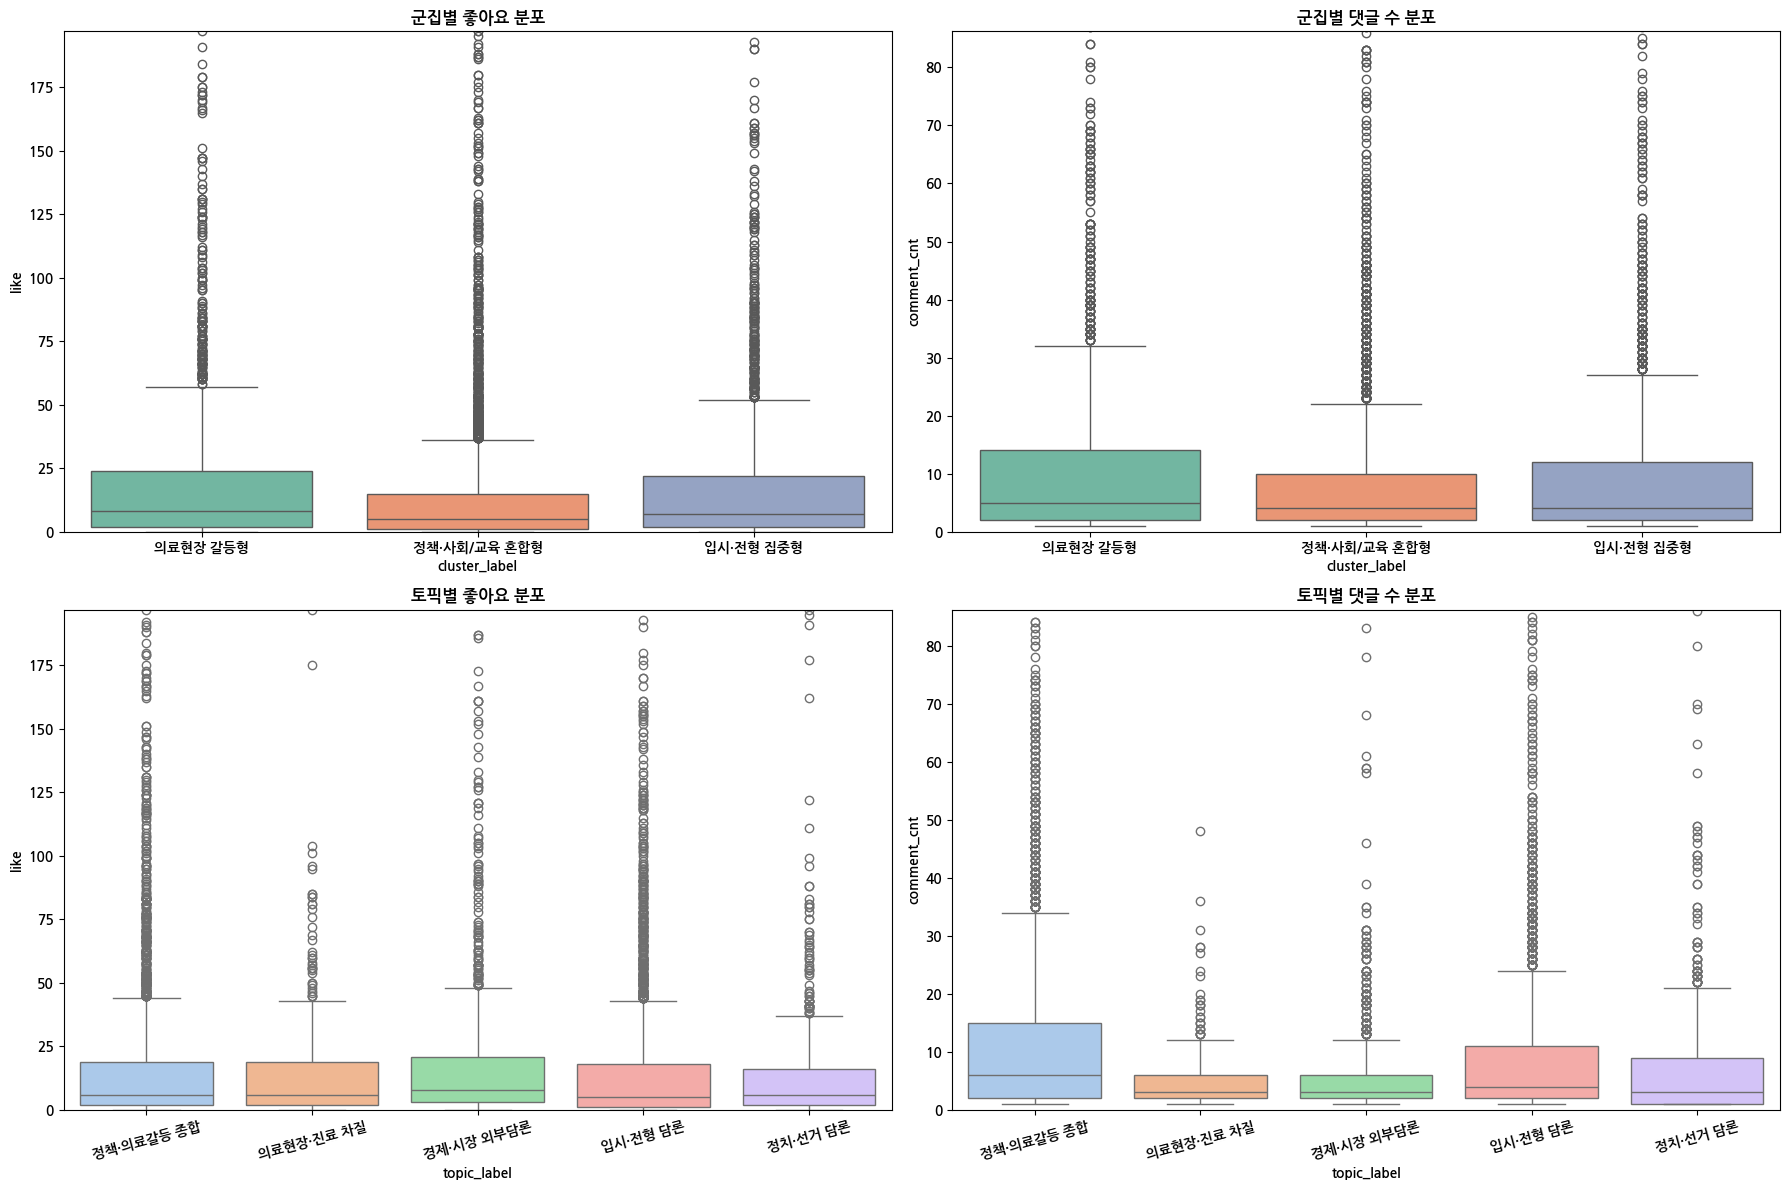

In [48]:
# 극단값 때문에 박스가 눌리지 않도록 99% 분위수를 y축 상한으로 사용합니다.
cluster_ylim_like = max(1, kmeans_doc_df["like"].quantile(0.99))
cluster_ylim_comment = max(1, kmeans_doc_df["comment_cnt"].quantile(0.99))

topic_ylim_like = max(1, lda_doc_df["like"].quantile(0.99))
topic_ylim_comment = max(1, lda_doc_df["comment_cnt"].quantile(0.99))

# 군집과 토픽별 좋아요·댓글 분포를 2x2 박스플롯으로 비교합니다.
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(
    data=kmeans_doc_df,
    x="cluster_label",
    y="like",
    hue="cluster_label",
    ax=axes[0, 0],
    palette="Set2",
    legend=False,
)
axes[0, 0].set_title("군집별 좋아요 분포")
axes[0, 0].set_ylim(0, cluster_ylim_like)

sns.boxplot(
    data=kmeans_doc_df,
    x="cluster_label",
    y="comment_cnt",
    hue="cluster_label",
    ax=axes[0, 1],
    palette="Set2",
    legend=False,
)
axes[0, 1].set_title("군집별 댓글 수 분포")
axes[0, 1].set_ylim(0, cluster_ylim_comment)

sns.boxplot(
    data=lda_doc_df,
    x="topic_label",
    y="like",
    hue="topic_label",
    ax=axes[1, 0],
    palette="pastel",
    legend=False,
)
axes[1, 0].set_title("토픽별 좋아요 분포")
axes[1, 0].set_ylim(0, topic_ylim_like)
axes[1, 0].tick_params(axis="x", rotation=15)

sns.boxplot(
    data=lda_doc_df,
    x="topic_label",
    y="comment_cnt",
    hue="topic_label",
    ax=axes[1, 1],
    palette="pastel",
    legend=False,
)
axes[1, 1].set_title("토픽별 댓글 수 분포")
axes[1, 1].set_ylim(0, topic_ylim_comment)
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(OUTPUTS_ANALYSIS_KMEANS / "boxplot_section_like_comment.png", dpi=150, bbox_inches="tight")
plt.show()


### 반응 지표 해석

의료현장 갈등형과 의료갈등 관련 토픽은 환자 피해, 진료 차질, 전공의 파업처럼 즉각적 불안을 자극해 댓글 논쟁을 크게 만들 가능성이 크다는 것을 알 수 있습니다. 
반면 입시·전형 담론은 폭발적 논쟁보다 수험생·학부모가 계속 확인하고 참고하는 실용적 관심에 가깝습니다.


### Step 5c — 구간별 반응 지표 시각화

군집·토픽 구분과 별도로, 1~4구간 자체의 좋아요 수와 댓글 수 분포를 비교합니다.  
이를 통해 특정 시기에 전반적인 공감 반응이나 논쟁 참여가 커졌는지 확인할 수 있습니다.

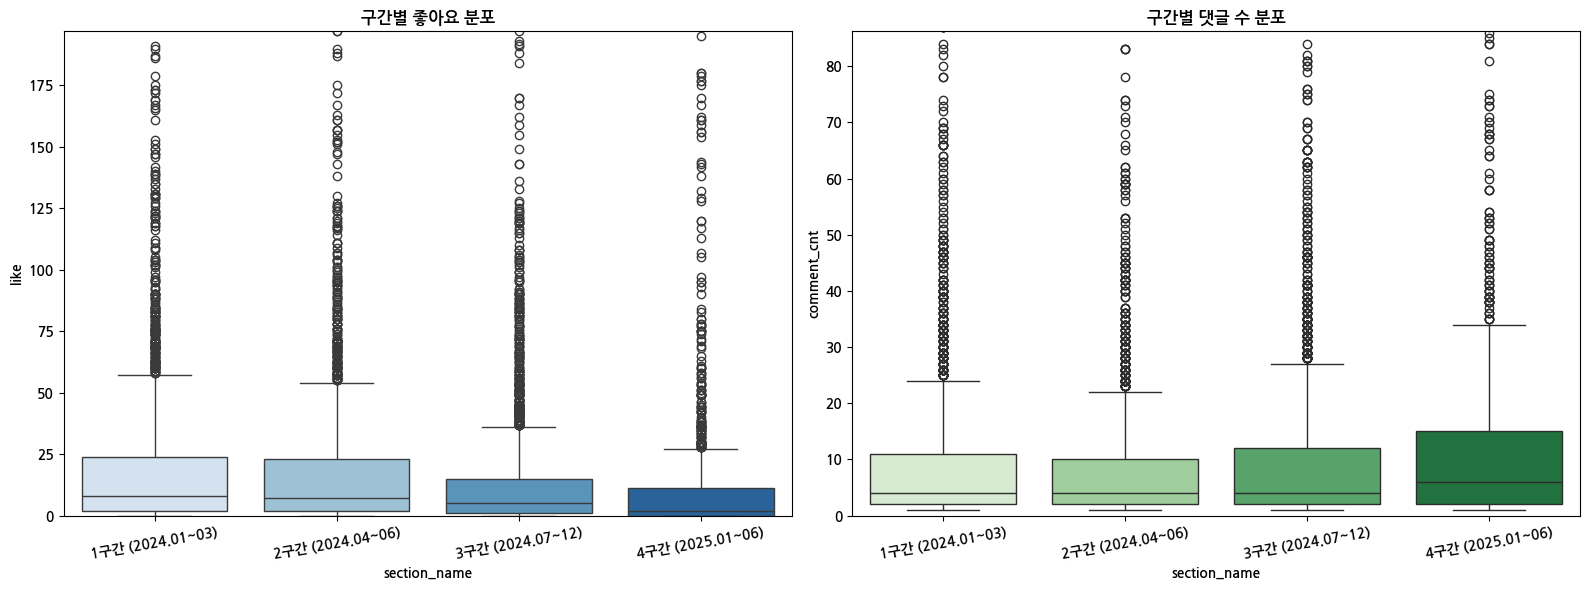

In [49]:
# 구간별 반응 지표도 극단값을 줄여 보기 위해 99% 분위수까지 표시합니다.
section_ylim_like = max(1, analysis_df["like"].quantile(0.99))
section_ylim_comment = max(1, analysis_df["comment_cnt"].quantile(0.99))

# 좋아요와 댓글 수를 나란히 비교하는 두 개의 박스플롯을 만듭니다.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=analysis_df,
    x="section_name",
    y="like",
    order=SECTION_ORDER,
    hue="section_name",
    hue_order=SECTION_ORDER,
    ax=axes[0],
    palette="Blues",
    legend=False,
)
axes[0].set_title("구간별 좋아요 분포")
axes[0].set_ylim(0, section_ylim_like)
axes[0].tick_params(axis="x", rotation=10)

sns.boxplot(
    data=analysis_df,
    x="section_name",
    y="comment_cnt",
    order=SECTION_ORDER,
    hue="section_name",
    hue_order=SECTION_ORDER,
    ax=axes[1],
    palette="Greens",
    legend=False,
)
axes[1].set_title("구간별 댓글 수 분포")
axes[1].set_ylim(0, section_ylim_comment)
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()


### Step 5 종합 해석

- TF-IDF와 빈도 결과를 함께 보면, 1구간은 `정부·정원·전공의·환자·진료`가 두드러져 정책 발표 직후 의료현장 갈등과 진료 차질 우려가 중심이었습니다.
- 2구간부터 `대학·전형·지역·학생·입시`가 강해지며 의대 증원이 대학 선발 방식과 지역 인재 논의로 번지기 시작했습니다.
- 3~4구간은 `수능·수시·지원·모집·정시·감사`가 반복적으로 나타나, 사람들의 관심이 정책 찬반보다 실제 지원 전략과 제도 검증으로 이동했음을 보여줍니다.

- K-Means 기준으로 `의료현장 갈등형`은 1구간 39.4%에서 4구간 8.4%로 감소했고, `입시·전형 집중형`은 1구간 15.7%에서 3구간 30.9%, 4구간 29.7%로 커졌습니다. `정책·사회/교육 혼합형`은 전 구간에서 큰 비중을 유지해 의대 증원이 정치·교육 이슈와 계속 결합되어 있음을 보여줍니다.
- LDA 기준으로도 `정책·의료갈등 종합`은 1구간 55.3%에서 4구간 35.1%로 낮아지고, `입시·전형 담론`은 1구간 21.7%에서 4구간 48.3%로 증가합니다. 서로 다른 모델이 같은 방향의 변화를 보여주므로, 담론 이동 해석의 신뢰도가 높아집니다.
- 즉, 반응 지표는 의료현장 갈등 담론이 댓글과 논쟁 참여를 강하게 만들고, 입시·전형 담론은 후반까지 지속되는 실용적 관심을 만든다는 점을 설명합니다.


## Step 6 — NMF 기반 담론 축 확인

K-Means와 LDA만으로 분석하면 군집 중심 또는 확률적 토픽에 해석이 치우칠 수 있다고 생각해, NMF(Non-negative Matrix Factorization) 분석을 활용해 TF-IDF 행렬에서 직접 담론 축을 분해합니다.

NMF는 TF-IDF처럼 0 이상의 값으로 구성된 행렬을 여러 개의 주제 성분으로 나누기 때문에, 특정 시기에 두드러지는 키워드 묶음을 비교적 직관적으로 확인할 수 있습니다. 여기서는 LDA와 같은 수의 성분을 사용해 두 모델의 해석이 얼마나 일관되는지 점검합니다.

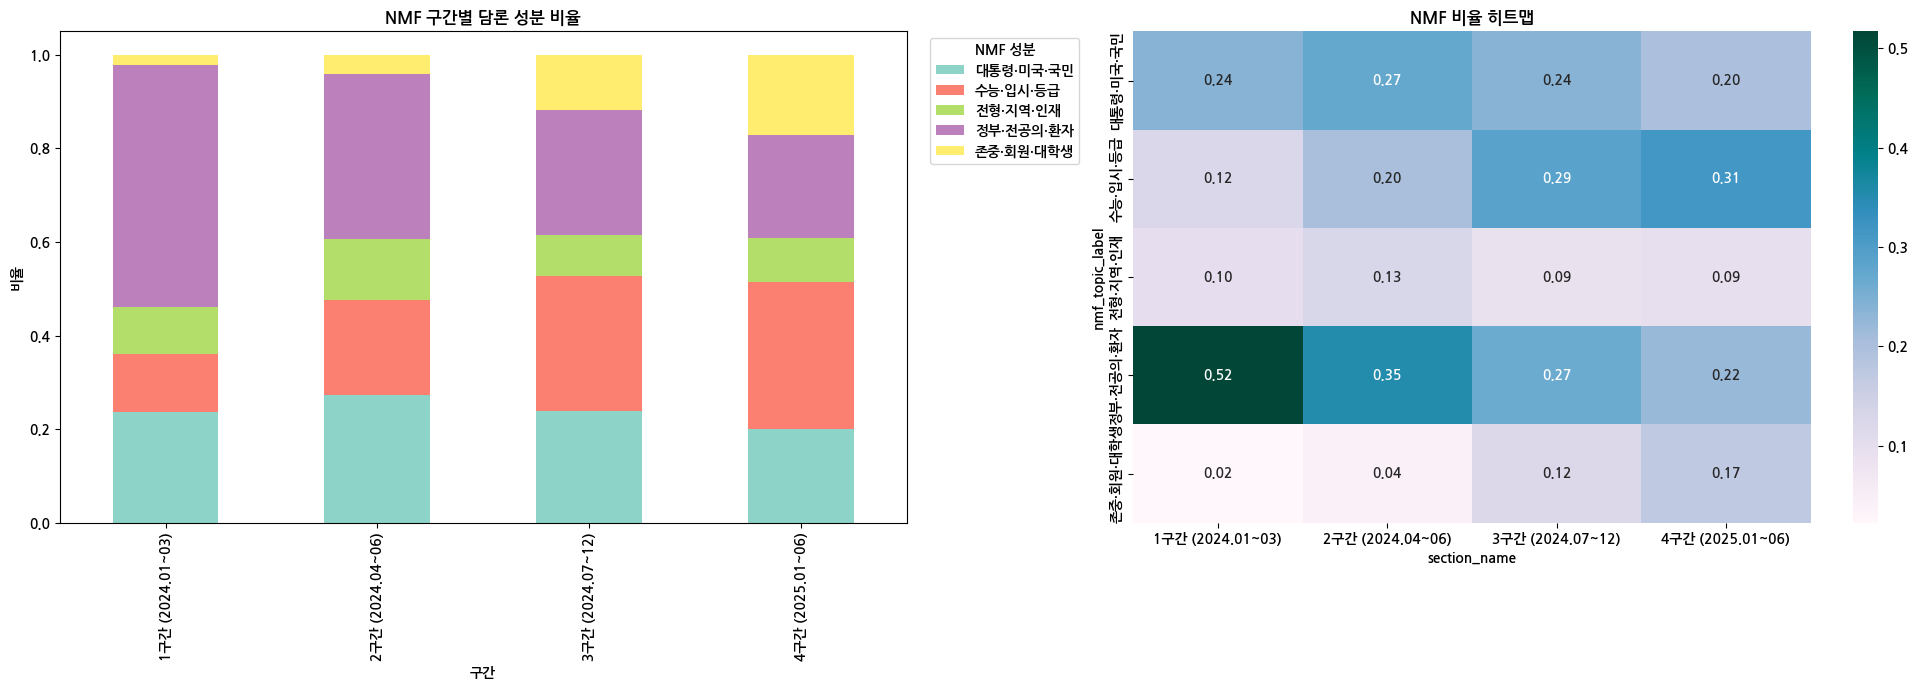

NMF 보완 분석 완료 — outputs under lda/


,nmf_topic,rank,keyword,weight,nmf_topic_label
0,0,1,전형,2.119927,전형·지역·인재
1,0,2,지역,1.623174,전형·지역·인재
2,0,3,인재,1.324429,전형·지역·인재
3,0,4,모집,1.207005,전형·지역·인재
4,0,5,대학,0.888932,전형·지역·인재
15,1,1,정부,1.242145,정부·전공의·환자
16,1,2,전공의,1.005514,정부·전공의·환자
17,1,3,환자,0.797192,정부·전공의·환자
18,1,4,교수,0.781833,정부·전공의·환자
19,1,5,정원,0.659072,정부·전공의·환자


In [ ]:
# 이 셀만 따로 실행해도 동작하도록 NMF를 한 번 더 import합니다.
from sklearn.decomposition import NMF

# NMF는 KMeans에서 만든 TF-IDF 행렬을 그대로 사용해 담론 성분을 분해합니다.
nmf_model = NMF(n_components=LDA_N_TOPICS, init="nndsvda", random_state=42, max_iter=500)
nmf_doc_topic = nmf_model.fit_transform(tfidf_matrix)
analysis_df["nmf_topic"] = nmf_doc_topic.argmax(axis=1)

nmf_top_terms_df = extract_top_terms(
    weights=nmf_model.components_,
    feature_names=tfidf_feature_names,
    item_name="nmf_topic",
    top_n=TOP_N_WORDS,
)

nmf_topic_label_map = (
    nmf_top_terms_df[nmf_top_terms_df["rank"] <= 3]
    .groupby("nmf_topic")["keyword"]
    .apply(lambda words: "·".join(words))
    .to_dict()
)
nmf_top_terms_df["nmf_topic_label"] = nmf_top_terms_df["nmf_topic"].map(nmf_topic_label_map)
save_csv_utf8(nmf_top_terms_df, LDA_DIR / "nmf_topic_top_terms.csv")

nmf_doc_df = analysis_df[
    ["title", "date", "section", "section_name", "like", "comment_cnt", "nmf_topic"]
].copy()
nmf_doc_df["nmf_topic_label"] = nmf_doc_df["nmf_topic"].map(nmf_topic_label_map)
save_csv_utf8(nmf_doc_df, LDA_DIR / "nmf_doc_assignments.csv")

nmf_section_distribution = build_section_ratio_table(nmf_doc_df, value_col="nmf_topic")
nmf_section_distribution["nmf_topic_label"] = nmf_section_distribution["nmf_topic"].map(nmf_topic_label_map)
save_csv_utf8(nmf_section_distribution, LDA_DIR / "nmf_section_distribution.csv")

nmf_pivot = nmf_section_distribution.pivot(
    index="section_name", columns="nmf_topic_label", values="ratio"
).reindex(index=SECTION_ORDER).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
nmf_pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set3")
axes[0].set_title("NMF 구간별 담론 성분 비율")
axes[0].set_xlabel("구간")
axes[0].set_ylabel("비율")
axes[0].legend(title="NMF 성분", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.heatmap(nmf_pivot.T, annot=True, fmt=".2f", cmap="PuBuGn", ax=axes[1])
axes[1].set_title("NMF 비율 히트맵")
plt.tight_layout()
plt.show()

print("NMF 보완 분석 완료 — outputs under lda/")
display(nmf_top_terms_df.groupby("nmf_topic").head(5))

### NMF 결과 해석 

NMF는 TF-IDF 가중치에서 직접 담론 성분을 분해하므로, LDA와 다른 방식으로도 같은 변화가 보이는지 확인하는 보완 근거입니다.

- `정부·전공의·환자` 성분은 1구간 51.7%에서 4구간 22.1%로 감소합니다. 초기에는 의대 증원이 의료공백, 전공의 이탈, 환자 피해 우려로 받아들여졌지만 후반으로 갈수록 이 담론의 상대적 비중은 낮아졌습니다.
- `수능·입시·등급` 성분은 1구간 12.4%에서 4구간 31.4%로 증가합니다. 시간이 지날수록 사람들은 증원 자체보다 수능 등급, 내신, 수시·정시 전략처럼 입시에 미치는 구체적 영향을 더 많이 이야기했습니다.
- `존중·회원·대학생` 성분은 1구간 2.2%에서 4구간 17.1%로 증가합니다. 이는 카페 커뮤니티에서 학부모·수험생·선배가 조언, 응원, 규정 확인을 주고받는 반응이 후반에 커졌음을 뜻합니다.

- `전형·지역·인재` 성분은 전 구간에서 9~13% 수준으로 유지되어 지역인재, 모집, 선발 방식 논의가 꾸준한 배경 관심사였음을 보여줍니다.
- `대통령·미국·국민` 성분은 정치·경제 외부담론이 섞인 축입니다. 의대 증원과 직접 연결되는 여론이라기보다 같은 시기 온라인 글에 함께 나타난 사회 일반 이슈로 보고, 최종 결론에서는 보조적 한계로 해석합니다.

따라서 NMF 결과도 전체 결론과 일치합니다. 

의대 증원에 대한 온라인 인식은 초기의 의료현장 갈등 우려에서 후반의 입시 전략, 전형 변화, 커뮤니티 조언 중심 반응으로 이동했습니다.

---

## 결론

이 분석의 결론은 의대 증원에 대한 온라인 인식이 시간에 따라 `의료현장 갈등`에서 `입시·전형 대응`으로 이동했다는 점입니다. TF-IDF와 워드클라우드는 1구간의 `정부·정원·전공의·환자·진료` 중심 반응이 후반으로 갈수록 `대학·전형·수능·입시·정시` 중심 반응으로 바뀌는 흐름을 보여줍니다.

KMeans에서는 `의료현장 갈등형`이 1구간 39.4%에서 4구간 8.4%로 줄고, `입시·전형 집중형`은 후반에 약 30% 수준까지 커집니다. LDA에서도 `정책·의료갈등 종합`은 55.3%에서 35.1%로 낮아지고, `입시·전형 담론`은 21.7%에서 48.3%로 증가합니다. NMF 역시 `정부·전공의·환자` 성분 감소와 `수능·입시·등급`, `존중·회원·대학생` 성분 증가를 보여주어 같은 결론을 보완합니다.

따라서 의대 증원은 처음에는 의료 공백과 정부 책임 논쟁으로 받아들여졌지만, 시간이 지나면서 수험생·학부모에게는 실제 지원 전략, 전형 변화, 등급 관리, 커뮤니티 조언의 문제로 재해석되었습니다.